# Analista de Crédito com IA

Este notebook constrói um fluxo de análise de risco de crédito usando a base **Home Credit Default Risk**. O objetivo é estimar a probabilidade de inadimplência de um cliente e transformar o resultado do modelo em uma análise textual de apoio à decisão.

O projeto combina quatro etapas:

1. preparação e inspeção dos dados;
2. criação de variáveis de risco de crédito;
3. treinamento e avaliação de modelos de classificação;
4. geração de uma recomendação em linguagem natural com IA generativa.

A previsão do modelo deve ser interpretada como apoio ao analista, não como decisão automática de crédito.

# Configuração do ambiente

Instalamos as bibliotecas necessárias para manipulação de dados, modelagem, download da base e integração com a Groq. Em ambiente local, as dependências também podem ser instaladas pelo terminal com `python -m pip install ...`.

In [26]:
!pip install openai scikit-learn pandas Groq kaggle xgboost lightgbm

# Imports

Carregamos as bibliotecas centrais do projeto. `pandas` e `numpy` sustentam a preparação de dados; as bibliotecas de machine learning entram nas seções de treino e avaliação.

In [27]:
import pandas as pd
import numpy as np
import os

# Download da base

Os arquivos CSV da competição são grandes e não ficam versionados no Git. O script `download_data.py` baixa e descompacta a base pelo Kaggle CLI quando os arquivos não existem localmente.

Para funcionar em uma máquina nova, é necessário autenticar o Kaggle antes, aceitando as regras da competição e configurando o token de API.

In [28]:
import subprocess
import sys

subprocess.run([sys.executable, "download_data.py"], check=True)

CompletedProcess(args=['c:\\Python314\\python.exe', 'download_data.py'], returncode=0)

In [29]:
df = pd.read_csv("application_train.csv")
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


# Inspeção inicial da tabela principal

Antes de selecionar variáveis, observamos tamanho, tipos, valores ausentes e alguns registros de `application_train.csv`. Essa inspeção ajuda a entender a qualidade dos dados e evita escolhas cegas de features.

A coluna `TARGET` é a variável que queremos prever: `1` indica inadimplência e `0` indica pagamento em dia.

In [30]:
def inspecionar_tabela(dataframe, nome, top_missing=20):
    print(f"Tabela: {nome}")
    print(f"Linhas: {dataframe.shape[0]:,}")
    print(f"Colunas: {dataframe.shape[1]:,}")

    resumo = pd.DataFrame({
        "dtype": dataframe.dtypes.astype(str),
        "missing_pct": dataframe.isna().mean().round(4),
        "nunique": dataframe.nunique(dropna=True)
    }).sort_values("missing_pct", ascending=False)

    display(resumo.head(top_missing))
    display(dataframe.head())


inspecionar_tabela(df, "application_train")

Tabela: application_train
Linhas: 307,511
Colunas: 122


,dtype,missing_pct,nunique
COMMONAREA_AVG,float64,0.6987,3181
COMMONAREA_MODE,float64,0.6987,3128
COMMONAREA_MEDI,float64,0.6987,3202
NONLIVINGAPARTMENTS_MEDI,float64,0.6943,214
NONLIVINGAPARTMENTS_MODE,float64,0.6943,167
NONLIVINGAPARTMENTS_AVG,float64,0.6943,386
FONDKAPREMONT_MODE,str,0.6839,4
LIVINGAPARTMENTS_AVG,float64,0.6835,1868
LIVINGAPARTMENTS_MEDI,float64,0.6835,1097
LIVINGAPARTMENTS_MODE,float64,0.6835,736


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


# Inspeção do histórico de crédito externo

A tabela `bureau.csv` contém créditos anteriores dos clientes em outras instituições financeiras. Como pode haver várias linhas para o mesmo cliente, ela precisa ser agregada por `SK_ID_CURR` antes de entrar no modelo.

Essas informações são úteis porque histórico de crédito externo costuma ser um dos sinais mais relevantes em análise de risco.

In [31]:
bureau = pd.read_csv("bureau.csv")
inspecionar_tabela(bureau, "bureau")

bureau_status = bureau["CREDIT_ACTIVE"].value_counts(dropna=False).to_frame("quantidade")
bureau_status["percentual"] = (bureau_status["quantidade"] / len(bureau)).round(4)
display(bureau_status)

Tabela: bureau
Linhas: 1,716,428
Colunas: 17


,dtype,missing_pct,nunique
AMT_ANNUITY,float64,0.7147,40321
AMT_CREDIT_MAX_OVERDUE,float64,0.6551,68251
DAYS_ENDDATE_FACT,float64,0.3692,2917
AMT_CREDIT_SUM_LIMIT,float64,0.3448,51726
AMT_CREDIT_SUM_DEBT,float64,0.1501,226537
DAYS_CREDIT_ENDDATE,float64,0.0615,14096
SK_ID_CURR,int64,0.0000,305811
DAYS_CREDIT,int64,0.0000,2923
SK_ID_BUREAU,int64,0.0000,1716428
CREDIT_DAY_OVERDUE,int64,0.0000,942


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


,quantidade,percentual
CREDIT_ACTIVE,,
Closed,1079273,0.6288
Active,630607,0.3674
Sold,6527,0.0038
Bad debt,21,0.0000


# Features de histórico de crédito externo

Nesta etapa, transformamos `bureau.csv` em uma tabela com uma linha por cliente. As agregações resumem volume de crédito, quantidade de contratos, situação ativa/fechada, dívidas, atrasos e proporções de risco.

Essas variáveis não usam o `TARGET`; portanto, ajudam o modelo sem introduzir vazamento de dados.

In [32]:
bureau_features = bureau.copy()

bureau_features["bureau_is_active"] = (bureau_features["CREDIT_ACTIVE"] == "Active").astype(int)
bureau_features["bureau_is_closed"] = (bureau_features["CREDIT_ACTIVE"] == "Closed").astype(int)
bureau_features["bureau_has_overdue"] = (bureau_features["CREDIT_DAY_OVERDUE"] > 0).astype(int)
bureau_features["bureau_credit_debt_ratio"] = (
    bureau_features["AMT_CREDIT_SUM_DEBT"] / bureau_features["AMT_CREDIT_SUM"].replace(0, np.nan)
)

bureau_agg = bureau_features.groupby("SK_ID_CURR").agg(
    bureau_credit_count=("SK_ID_BUREAU", "count"),
    bureau_active_count=("bureau_is_active", "sum"),
    bureau_closed_count=("bureau_is_closed", "sum"),
    bureau_overdue_count=("bureau_has_overdue", "sum"),
    bureau_days_credit_mean=("DAYS_CREDIT", "mean"),
    bureau_days_credit_min=("DAYS_CREDIT", "min"),
    bureau_days_credit_max=("DAYS_CREDIT", "max"),
    bureau_credit_day_overdue_max=("CREDIT_DAY_OVERDUE", "max"),
    bureau_credit_prolong_sum=("CNT_CREDIT_PROLONG", "sum"),
    bureau_credit_sum_total=("AMT_CREDIT_SUM", "sum"),
    bureau_credit_sum_mean=("AMT_CREDIT_SUM", "mean"),
    bureau_debt_sum_total=("AMT_CREDIT_SUM_DEBT", "sum"),
    bureau_debt_sum_mean=("AMT_CREDIT_SUM_DEBT", "mean"),
    bureau_overdue_sum_total=("AMT_CREDIT_SUM_OVERDUE", "sum"),
    bureau_limit_sum_total=("AMT_CREDIT_SUM_LIMIT", "sum"),
    bureau_annuity_sum_total=("AMT_ANNUITY", "sum"),
    bureau_credit_debt_ratio_mean=("bureau_credit_debt_ratio", "mean"),
    bureau_credit_debt_ratio_max=("bureau_credit_debt_ratio", "max")
).reset_index()

bureau_agg["bureau_active_ratio"] = bureau_agg["bureau_active_count"] / bureau_agg["bureau_credit_count"].replace(0, np.nan)
bureau_agg["bureau_overdue_ratio"] = bureau_agg["bureau_overdue_count"] / bureau_agg["bureau_credit_count"].replace(0, np.nan)
bureau_agg["bureau_debt_credit_ratio_total"] = bureau_agg["bureau_debt_sum_total"] / bureau_agg["bureau_credit_sum_total"].replace(0, np.nan)

bureau_feature_cols = [col for col in bureau_agg.columns if col != "SK_ID_CURR"]

df = df.merge(bureau_agg, on="SK_ID_CURR", how="left")

print(f"Features criadas a partir de bureau.csv: {len(bureau_feature_cols)}")
display(bureau_agg.head())

Features criadas a partir de bureau.csv: 21


,SK_ID_CURR,bureau_credit_count,bureau_active_count,bureau_closed_count,bureau_overdue_count,bureau_days_credit_mean,bureau_days_credit_min,bureau_days_credit_max,bureau_credit_day_overdue_max,bureau_credit_prolong_sum,...,bureau_debt_sum_total,bureau_debt_sum_mean,bureau_overdue_sum_total,bureau_limit_sum_total,bureau_annuity_sum_total,bureau_credit_debt_ratio_mean,bureau_credit_debt_ratio_max,bureau_active_ratio,bureau_overdue_ratio,bureau_debt_credit_ratio_total
0,100001,7,3,4,0,-735.000000,-1572,-49,0,0,...,596686.5,85240.928571,0.0,0.000,24817.5,0.282518,0.987405,0.428571,0.0,0.410555
1,100002,8,2,6,0,-874.000000,-1437,-103,0,0,...,245781.0,49156.200000,0.0,31988.565,0.0,0.136545,0.546180,0.250000,0.0,0.284122
2,100003,4,1,3,0,-1400.750000,-2586,-606,0,0,...,0.0,0.000000,0.0,810000.000,0.0,0.000000,0.000000,0.250000,0.0,0.000000
3,100004,2,0,2,0,-867.000000,-1326,-408,0,0,...,0.0,0.000000,0.0,0.000,0.0,0.000000,0.000000,0.000000,0.0,0.000000
4,100005,3,2,1,0,-190.666667,-373,-62,0,0,...,568408.5,189469.500000,0.0,0.000,4261.5,0.601256,0.954794,0.666667,0.0,0.864992


# Features mensais do histórico externo

A tabela `bureau_balance.csv` detalha o status mensal de cada crédito presente em `bureau.csv`. Primeiro resumimos o histórico mensal por `SK_ID_BUREAU`; depois conectamos esse resumo ao cliente por meio de `bureau.csv`.

O objetivo é capturar sinais como meses com atraso, atraso severo e proporção de meses encerrados.

In [33]:
bureau_balance = pd.read_csv("bureau_balance.csv")
inspecionar_tabela(bureau_balance, "bureau_balance")

bureau_balance_features = bureau_balance.copy()
bureau_balance_features["bb_status_num"] = bureau_balance_features["STATUS"].replace({
    "X": np.nan,
    "C": 0,
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5
}).astype(float)
bureau_balance_features["bb_has_late_status"] = (bureau_balance_features["bb_status_num"] >= 1).astype(int)
bureau_balance_features["bb_has_severe_late_status"] = (bureau_balance_features["bb_status_num"] >= 3).astype(int)
bureau_balance_features["bb_is_closed"] = (bureau_balance_features["STATUS"] == "C").astype(int)

bureau_balance_by_bureau = bureau_balance_features.groupby("SK_ID_BUREAU").agg(
    bb_month_count=("MONTHS_BALANCE", "count"),
    bb_month_min=("MONTHS_BALANCE", "min"),
    bb_month_max=("MONTHS_BALANCE", "max"),
    bb_status_mean=("bb_status_num", "mean"),
    bb_status_max=("bb_status_num", "max"),
    bb_late_months=("bb_has_late_status", "sum"),
    bb_severe_late_months=("bb_has_severe_late_status", "sum"),
    bb_closed_months=("bb_is_closed", "sum")
).reset_index()

bureau_balance_by_bureau["bb_late_month_ratio"] = (
    bureau_balance_by_bureau["bb_late_months"] / bureau_balance_by_bureau["bb_month_count"].replace(0, np.nan)
)
bureau_balance_by_bureau["bb_severe_late_month_ratio"] = (
    bureau_balance_by_bureau["bb_severe_late_months"] / bureau_balance_by_bureau["bb_month_count"].replace(0, np.nan)
)
bureau_balance_by_bureau["bb_closed_month_ratio"] = (
    bureau_balance_by_bureau["bb_closed_months"] / bureau_balance_by_bureau["bb_month_count"].replace(0, np.nan)
)

bureau_with_balance = bureau[["SK_ID_CURR", "SK_ID_BUREAU"]].merge(
    bureau_balance_by_bureau,
    on="SK_ID_BUREAU",
    how="left"
)

bureau_balance_agg = bureau_with_balance.groupby("SK_ID_CURR").agg(
    bb_bureau_count=("SK_ID_BUREAU", "count"),
    bb_month_count_mean=("bb_month_count", "mean"),
    bb_month_count_sum=("bb_month_count", "sum"),
    bb_status_mean=("bb_status_mean", "mean"),
    bb_status_max=("bb_status_max", "max"),
    bb_late_months_sum=("bb_late_months", "sum"),
    bb_severe_late_months_sum=("bb_severe_late_months", "sum"),
    bb_late_month_ratio_mean=("bb_late_month_ratio", "mean"),
    bb_late_month_ratio_max=("bb_late_month_ratio", "max"),
    bb_severe_late_month_ratio_mean=("bb_severe_late_month_ratio", "mean"),
    bb_closed_month_ratio_mean=("bb_closed_month_ratio", "mean")
).reset_index()

bureau_balance_feature_cols = [col for col in bureau_balance_agg.columns if col != "SK_ID_CURR"]

df = df.merge(bureau_balance_agg, on="SK_ID_CURR", how="left")

print(f"Features criadas a partir de bureau_balance.csv: {len(bureau_balance_feature_cols)}")
display(bureau_balance_agg.head())

Tabela: bureau_balance
Linhas: 27,299,925
Colunas: 3


,dtype,missing_pct,nunique
SK_ID_BUREAU,int64,0.0,817395
MONTHS_BALANCE,int64,0.0,97
STATUS,str,0.0,8


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


Features criadas a partir de bureau_balance.csv: 11


,SK_ID_CURR,bb_bureau_count,bb_month_count_mean,bb_month_count_sum,bb_status_mean,bb_status_max,bb_late_months_sum,bb_severe_late_months_sum,bb_late_month_ratio_mean,bb_late_month_ratio_max,bb_severe_late_month_ratio_mean,bb_closed_month_ratio_mean
0,100001,7,24.571429,172.0,0.010989,1.0,1.0,0.0,0.007519,0.052632,0.0,0.441240
1,100002,8,13.750000,110.0,0.299222,1.0,27.0,0.0,0.255682,0.500000,0.0,0.175426
2,100003,4,NaN,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,100004,2,NaN,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,100005,3,7.000000,21.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.128205


# Histórico de solicitações anteriores

A tabela `previous_application.csv` registra pedidos anteriores feitos pelo cliente. Ela ajuda a capturar comportamento histórico com a própria instituição, como quantidade de aprovações, recusas, valores solicitados e diferença entre crédito pedido e concedido.

In [34]:
previous_application = pd.read_csv("previous_application.csv")
inspecionar_tabela(previous_application, "previous_application")

previous_features = previous_application.copy()

# Na base Home Credit, valores 365243 em colunas temporais representam marcador especial.
previous_days_cols = [
    "DAYS_DECISION",
    "DAYS_FIRST_DRAWING",
    "DAYS_FIRST_DUE",
    "DAYS_LAST_DUE_1ST_VERSION",
    "DAYS_LAST_DUE",
    "DAYS_TERMINATION"
]
for col in previous_days_cols:
    if col in previous_features.columns:
        previous_features[col] = previous_features[col].replace(365243, np.nan)

previous_features["prev_is_approved"] = (previous_features["NAME_CONTRACT_STATUS"] == "Approved").astype(int)
previous_features["prev_is_refused"] = (previous_features["NAME_CONTRACT_STATUS"] == "Refused").astype(int)
previous_features["prev_is_canceled"] = (previous_features["NAME_CONTRACT_STATUS"] == "Canceled").astype(int)
previous_features["prev_credit_application_ratio"] = (
    previous_features["AMT_CREDIT"] / previous_features["AMT_APPLICATION"].replace(0, np.nan)
)
previous_features["prev_down_payment_ratio"] = (
    previous_features["AMT_DOWN_PAYMENT"] / previous_features["AMT_APPLICATION"].replace(0, np.nan)
)
previous_features["prev_annuity_credit_ratio"] = (
    previous_features["AMT_ANNUITY"] / previous_features["AMT_CREDIT"].replace(0, np.nan)
)

previous_application_agg = previous_features.groupby("SK_ID_CURR").agg(
    prev_application_count=("SK_ID_PREV", "count"),
    prev_approved_count=("prev_is_approved", "sum"),
    prev_refused_count=("prev_is_refused", "sum"),
    prev_canceled_count=("prev_is_canceled", "sum"),
    prev_days_decision_mean=("DAYS_DECISION", "mean"),
    prev_days_decision_min=("DAYS_DECISION", "min"),
    prev_days_decision_max=("DAYS_DECISION", "max"),
    prev_amt_application_sum=("AMT_APPLICATION", "sum"),
    prev_amt_application_mean=("AMT_APPLICATION", "mean"),
    prev_amt_credit_sum=("AMT_CREDIT", "sum"),
    prev_amt_credit_mean=("AMT_CREDIT", "mean"),
    prev_amt_annuity_mean=("AMT_ANNUITY", "mean"),
    prev_amt_down_payment_mean=("AMT_DOWN_PAYMENT", "mean"),
    prev_credit_application_ratio_mean=("prev_credit_application_ratio", "mean"),
    prev_credit_application_ratio_max=("prev_credit_application_ratio", "max"),
    prev_down_payment_ratio_mean=("prev_down_payment_ratio", "mean"),
    prev_annuity_credit_ratio_mean=("prev_annuity_credit_ratio", "mean"),
    prev_hour_process_mean=("HOUR_APPR_PROCESS_START", "mean"),
    prev_nflag_last_appl_sum=("NFLAG_LAST_APPL_IN_DAY", "sum")
).reset_index()

previous_application_agg["prev_approved_ratio"] = (
    previous_application_agg["prev_approved_count"] / previous_application_agg["prev_application_count"].replace(0, np.nan)
)
previous_application_agg["prev_refused_ratio"] = (
    previous_application_agg["prev_refused_count"] / previous_application_agg["prev_application_count"].replace(0, np.nan)
)
previous_application_agg["prev_canceled_ratio"] = (
    previous_application_agg["prev_canceled_count"] / previous_application_agg["prev_application_count"].replace(0, np.nan)
)
previous_application_agg["prev_credit_application_diff_total"] = (
    previous_application_agg["prev_amt_credit_sum"] - previous_application_agg["prev_amt_application_sum"]
)

previous_application_feature_cols = [col for col in previous_application_agg.columns if col != "SK_ID_CURR"]

df = df.merge(previous_application_agg, on="SK_ID_CURR", how="left")

print(f"Features criadas a partir de previous_application.csv: {len(previous_application_feature_cols)}")
display(previous_application_agg.head())

Tabela: previous_application
Linhas: 1,670,214
Colunas: 37


,dtype,missing_pct,nunique
RATE_INTEREST_PRIVILEGED,float64,0.9964,25
RATE_INTEREST_PRIMARY,float64,0.9964,148
AMT_DOWN_PAYMENT,float64,0.5364,29278
RATE_DOWN_PAYMENT,float64,0.5364,207033
NAME_TYPE_SUITE,str,0.4912,7
DAYS_TERMINATION,float64,0.4030,2830
DAYS_FIRST_DRAWING,float64,0.4030,2838
DAYS_FIRST_DUE,float64,0.4030,2892
DAYS_LAST_DUE_1ST_VERSION,float64,0.4030,4605
DAYS_LAST_DUE,float64,0.4030,2873


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


Features criadas a partir de previous_application.csv: 23


,SK_ID_CURR,prev_application_count,prev_approved_count,prev_refused_count,prev_canceled_count,prev_days_decision_mean,prev_days_decision_min,prev_days_decision_max,prev_amt_application_sum,prev_amt_application_mean,...,prev_credit_application_ratio_mean,prev_credit_application_ratio_max,prev_down_payment_ratio_mean,prev_annuity_credit_ratio_mean,prev_hour_process_mean,prev_nflag_last_appl_sum,prev_approved_ratio,prev_refused_ratio,prev_canceled_ratio,prev_credit_application_diff_total
0,100001,1,1,0,0,-1740.0,-1740,-1740,24835.5,24835.50,...,0.957782,0.957782,0.101468,0.166099,13.000000,1,1.0,0.0,0.0,-1048.5
1,100002,1,1,0,0,-606.0,-606,-606,179055.0,179055.00,...,1.000000,1.000000,0.000000,0.051670,9.000000,1,1.0,0.0,0.0,0.0
2,100003,3,3,0,0,-1305.0,-2341,-746,1306309.5,435436.50,...,1.057664,1.150980,0.050029,0.126383,14.666667,3,1.0,0.0,0.0,146263.5
3,100004,1,1,0,0,-815.0,-815,-815,24282.0,24282.00,...,0.828021,0.828021,0.200148,0.266450,5.000000,1,1.0,0.0,0.0,-4176.0
4,100005,2,1,0,1,-536.0,-757,-315,44617.5,22308.75,...,0.899950,0.899950,0.100050,0.119870,10.500000,2,0.5,0.0,0.5,-4464.0


# Histórico de pagamentos anteriores

A tabela `installments_payments.csv` registra parcelas esperadas e pagamentos realizados em contratos anteriores. Ela é importante porque captura comportamento real de pagamento, como atraso, pagamento parcial e diferença entre valor pago e valor devido.

In [35]:
installments_payments = pd.read_csv("installments_payments.csv")
inspecionar_tabela(installments_payments, "installments_payments")

installments_features = installments_payments.copy()
installments_features["inst_days_late"] = (
    installments_features["DAYS_ENTRY_PAYMENT"] - installments_features["DAYS_INSTALMENT"]
)
installments_features["inst_is_late"] = (installments_features["inst_days_late"] > 0).astype(int)
installments_features["inst_payment_ratio"] = (
    installments_features["AMT_PAYMENT"] / installments_features["AMT_INSTALMENT"].replace(0, np.nan)
)
installments_features["inst_payment_diff"] = (
    installments_features["AMT_PAYMENT"] - installments_features["AMT_INSTALMENT"]
)
installments_features["inst_is_underpaid"] = (installments_features["inst_payment_diff"] < 0).astype(int)

installments_payments_agg = installments_features.groupby("SK_ID_CURR").agg(
    inst_payment_count=("SK_ID_PREV", "count"),
    inst_prev_contract_count=("SK_ID_PREV", "nunique"),
    inst_days_late_mean=("inst_days_late", "mean"),
    inst_days_late_max=("inst_days_late", "max"),
    inst_late_payment_count=("inst_is_late", "sum"),
    inst_underpaid_count=("inst_is_underpaid", "sum"),
    inst_payment_ratio_mean=("inst_payment_ratio", "mean"),
    inst_payment_ratio_min=("inst_payment_ratio", "min"),
    inst_payment_ratio_max=("inst_payment_ratio", "max"),
    inst_payment_diff_mean=("inst_payment_diff", "mean"),
    inst_payment_diff_sum=("inst_payment_diff", "sum"),
    inst_amt_instalment_sum=("AMT_INSTALMENT", "sum"),
    inst_amt_payment_sum=("AMT_PAYMENT", "sum")
).reset_index()

installments_payments_agg["inst_late_payment_ratio"] = (
    installments_payments_agg["inst_late_payment_count"] / installments_payments_agg["inst_payment_count"].replace(0, np.nan)
)
installments_payments_agg["inst_underpaid_ratio"] = (
    installments_payments_agg["inst_underpaid_count"] / installments_payments_agg["inst_payment_count"].replace(0, np.nan)
)
installments_payments_agg["inst_total_payment_ratio"] = (
    installments_payments_agg["inst_amt_payment_sum"] / installments_payments_agg["inst_amt_instalment_sum"].replace(0, np.nan)
)

installments_payment_feature_cols = [col for col in installments_payments_agg.columns if col != "SK_ID_CURR"]

df = df.merge(installments_payments_agg, on="SK_ID_CURR", how="left")

print(f"Features criadas a partir de installments_payments.csv: {len(installments_payment_feature_cols)}")
display(installments_payments_agg.head())

Tabela: installments_payments
Linhas: 13,605,401
Colunas: 8


,dtype,missing_pct,nunique
AMT_PAYMENT,float64,0.0002,944235
DAYS_ENTRY_PAYMENT,float64,0.0002,3039
SK_ID_PREV,int64,0.0000,997752
SK_ID_CURR,int64,0.0000,339587
NUM_INSTALMENT_NUMBER,int64,0.0000,277
NUM_INSTALMENT_VERSION,float64,0.0000,65
DAYS_INSTALMENT,float64,0.0000,2922
AMT_INSTALMENT,float64,0.0000,902539


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


Features criadas a partir de installments_payments.csv: 16


,SK_ID_CURR,inst_payment_count,inst_prev_contract_count,inst_days_late_mean,inst_days_late_max,inst_late_payment_count,inst_underpaid_count,inst_payment_ratio_mean,inst_payment_ratio_min,inst_payment_ratio_max,inst_payment_diff_mean,inst_payment_diff_sum,inst_amt_instalment_sum,inst_amt_payment_sum,inst_late_payment_ratio,inst_underpaid_ratio,inst_total_payment_ratio
0,100001,7,2,-7.285714,11.0,1,0,1.0,1.0,1.0,0.0,0.0,41195.925,41195.925,0.142857,0.0,1.0
1,100002,19,1,-20.421053,-12.0,0,0,1.0,1.0,1.0,0.0,0.0,219625.695,219625.695,0.000000,0.0,1.0
2,100003,25,3,-7.160000,-1.0,0,0,1.0,1.0,1.0,0.0,0.0,1618864.650,1618864.650,0.000000,0.0,1.0
3,100004,3,1,-7.666667,-3.0,0,0,1.0,1.0,1.0,0.0,0.0,21288.465,21288.465,0.000000,0.0,1.0
4,100005,9,1,-23.555556,1.0,1,0,1.0,1.0,1.0,0.0,0.0,56161.845,56161.845,0.111111,0.0,1.0


# Seleção de variáveis

Selecionamos variáveis da tabela principal e adicionamos as features agregadas das tabelas auxiliares. A seleção combina variáveis financeiras, demográficas, comportamentais e de histórico externo.

Mantemos `SK_ID_CURR` apenas como chave de junção; ele não entra como variável preditiva no treinamento.

In [36]:
base_cols = [
    "SK_ID_CURR",
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_EMPLOYED",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

new_num_cols = [
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH",
    "DAYS_LAST_PHONE_CHANGE",
    "REGION_POPULATION_RELATIVE",
    "REGION_RATING_CLIENT",
    "REGION_RATING_CLIENT_W_CITY",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "DEF_60_CNT_SOCIAL_CIRCLE",
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "REG_CITY_NOT_WORK_CITY",
    "REG_CITY_NOT_LIVE_CITY",
    "LIVE_CITY_NOT_WORK_CITY",
    "FLAG_EMP_PHONE",
    "FLAG_DOCUMENT_3"
]

cat_features = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "NAME_TYPE_SUITE"
]

cols = list(dict.fromkeys(base_cols + new_num_cols + cat_features + globals().get("bureau_feature_cols", []) + globals().get("bureau_balance_feature_cols", []) + globals().get("previous_application_feature_cols", []) + globals().get("installments_payment_feature_cols", [])))

df = df[cols].copy()

# Na base Home Credit, 365243 representa um valor especial para clientes sem emprego registrado.
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

df.head()

,SK_ID_CURR,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,AMT_GOODS_PRICE,...,inst_payment_ratio_mean,inst_payment_ratio_min,inst_payment_ratio_max,inst_payment_diff_mean,inst_payment_diff_sum,inst_amt_instalment_sum,inst_amt_payment_sum,inst_late_payment_ratio,inst_underpaid_ratio,inst_total_payment_ratio
0,100002,1,202500.0,406597.5,24700.5,-637.0,0.083037,0.262949,0.139376,351000.0,...,1.000000,1.00000,1.0,0.000000,0.000,219625.695,219625.695,0.000000,0.000000,1.000000
1,100003,0,270000.0,1293502.5,35698.5,-1188.0,0.311267,0.622246,NaN,1129500.0,...,1.000000,1.00000,1.0,0.000000,0.000,1618864.650,1618864.650,0.000000,0.000000,1.000000
2,100004,0,67500.0,135000.0,6750.0,-225.0,NaN,0.555912,0.729567,135000.0,...,1.000000,1.00000,1.0,0.000000,0.000,21288.465,21288.465,0.000000,0.000000,1.000000
3,100006,0,135000.0,312682.5,29686.5,-3039.0,NaN,0.650442,NaN,297000.0,...,1.000000,1.00000,1.0,0.000000,0.000,1007153.415,1007153.415,0.000000,0.000000,1.000000
4,100007,0,121500.0,513000.0,21865.5,-3038.0,NaN,0.322738,NaN,513000.0,...,0.954545,0.00005,1.0,-452.384318,-29857.365,835985.340,806127.975,0.242424,0.090909,0.964285


# Feature Engineering

Criamos variáveis derivadas que traduzem relações financeiras e temporais importantes para crédito. Em vez de usar apenas valores absolutos, calculamos razões e indicadores mais interpretáveis.

Principais variáveis criadas:

- `dti`: quanto da renda está comprometida pela anuidade do crédito;
- `credit_income_ratio`: tamanho do crédito em relação à renda;
- `annuity_credit_ratio`: peso da parcela anual em relação ao crédito;
- `goods_credit_ratio`: relação entre valor do bem e valor do crédito;
- `income_per_family_member`: renda ajustada pelo tamanho da família;
- estatísticas de `EXT_SOURCE`: média, mínimo e máximo das fontes externas de score.

In [37]:
df["DAYS_BIRTH_YEARS"] = (-df["DAYS_BIRTH"]) / 365

for col in ["DAYS_EMPLOYED", "DAYS_REGISTRATION", "DAYS_ID_PUBLISH", "DAYS_LAST_PHONE_CHANGE"]:
    df[f"{col}_YEARS"] = (-df[col]) / 365

df["dti"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
df["credit_income_ratio"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
df["annuity_credit_ratio"] = df["AMT_ANNUITY"] / df["AMT_CREDIT"]
df["goods_credit_ratio"] = df["AMT_GOODS_PRICE"] / df["AMT_CREDIT"]
df["income_per_family_member"] = df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"].replace(0, np.nan)

df["ext_source_mean"] = df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].mean(axis=1)
df["ext_source_min"] = df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].min(axis=1)
df["ext_source_max"] = df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].max(axis=1)

# Treinamento dos modelos

A base é separada em treino, calibração e teste, preservando a proporção de inadimplentes. Como a classe inadimplente é minoritária, usamos estratégias de balanceamento nos modelos.

O pré-processamento é feito com `ColumnTransformer`:

- variáveis numéricas recebem imputação por mediana e, na regressão logística, padronização;
- variáveis categóricas recebem imputação pela moda e `OneHotEncoder`.

Modelos treinados nesta etapa:

- Regressão Logística, como baseline interpretável;
- Random Forest, como modelo de árvores robusto;
- XGBoost, como boosting gradiente eficiente para dados tabulares;
- LightGBM, como boosting gradiente rápido e competitivo em bases grandes.

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

engineered_num_cols = [
    "DAYS_BIRTH_YEARS",
    "DAYS_EMPLOYED_YEARS",
    "DAYS_REGISTRATION_YEARS",
    "DAYS_ID_PUBLISH_YEARS",
    "DAYS_LAST_PHONE_CHANGE_YEARS",
    "dti",
    "credit_income_ratio",
    "annuity_credit_ratio",
    "goods_credit_ratio",
    "income_per_family_member",
    "ext_source_mean",
    "ext_source_min",
    "ext_source_max"
]

bureau_feature_cols = [
    col for col in globals().get("bureau_feature_cols", [])
    if col in df.columns
]

bureau_balance_feature_cols = [
    col for col in globals().get("bureau_balance_feature_cols", [])
    if col in df.columns
]

previous_application_feature_cols = [
    col for col in globals().get("previous_application_feature_cols", [])
    if col in df.columns
]

installments_payment_feature_cols = [
    col for col in globals().get("installments_payment_feature_cols", [])
    if col in df.columns
]

num_features = [
    col for col in base_cols[2:] + new_num_cols + engineered_num_cols + bureau_feature_cols + bureau_balance_feature_cols + previous_application_feature_cols + installments_payment_feature_cols
    if col in df.columns
]

X = df[num_features + cat_features]
y = df["TARGET"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_calib, y_train, y_calib = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

numeric_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_lr = ColumnTransformer(transformers=[
    ("num", numeric_lr, num_features),
    ("cat", categorical, cat_features)
])

preprocess_tree = ColumnTransformer(transformers=[
    ("num", numeric_tree, num_features),
    ("cat", categorical, cat_features)
])

print(f"Variáveis numéricas: {len(num_features)}")
print(f"Variáveis categóricas: {len(cat_features)}")
print(f"Features de bureau: {len(bureau_feature_cols)}")
print(f"Features de bureau_balance: {len(bureau_balance_feature_cols)}")
print(f"Features de previous_application: {len(previous_application_feature_cols)}")
print(f"Features de installments_payments: {len(installments_payment_feature_cols)}")
print(f"Treino: {len(X_train):,} | Calibração: {len(X_calib):,} | Teste: {len(X_test):,}")

Variáveis numéricas: 109
Variáveis categóricas: 10
Features de bureau: 21
Features de bureau_balance: 11
Features de previous_application: 23
Features de installments_payments: 16
Treino: 196,806 | Calibração: 49,202 | Teste: 61,503


In [39]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

modelLR = Pipeline(steps=[
    ("preprocess", preprocess_lr),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

modelLR.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [40]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

modelRF = Pipeline(steps=[
    ("preprocess", preprocess_tree),
    ("model", RandomForestClassifier(
        n_estimators=150,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=50
    ))
])

modelRF.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [41]:
# XGBoost
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

modelXGB = Pipeline(steps=[
    ("preprocess", preprocess_tree),
    ("model", XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="auc",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])

modelXGB.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [42]:
# LightGBM
from lightgbm import LGBMClassifier

modelLGBM = Pipeline(steps=[
    ("preprocess", preprocess_tree),
    ("model", LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

modelLGBM.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

# Avaliação dos modelos

A base é desbalanceada, então a AUC é importante, mas não basta sozinha. Também olhamos precisão, recall e matriz de confusão para entender o comportamento do modelo na classe de inadimplência.

Em crédito, recall alto ajuda a capturar clientes arriscados, mas pode aumentar falsos positivos. Por isso, a escolha do threshold deve considerar a política de risco do negócio.

c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Taxa de inadimplência no teste: 8.07%
LightGBM - AUC: 0.7817
XGBoost - AUC: 0.7813
Regressão Logística - AUC: 0.7656
Random Forest - AUC: 0.7628

Modelo escolhido: LightGBM
Relatório de classificação - LightGBM
              precision    recall  f1-score   support

           0      0.963     0.746     0.841     56538
           1      0.189     0.674     0.295      4965

    accuracy                          0.740     61503
   macro avg      0.576     0.710     0.568     61503
weighted avg      0.901     0.740     0.797     61503

Matriz de confusão - LightGBM
[[42187 14351]
 [ 1619  3346]]


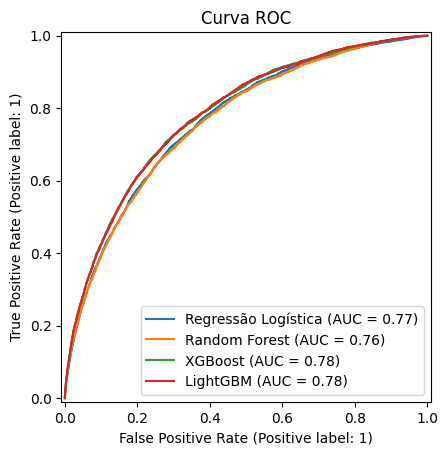

In [43]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

modelos = {
    "Regressão Logística": modelLR,
    "Random Forest": modelRF,
    "XGBoost": modelXGB,
    "LightGBM": modelLGBM
}

predicoes_modelos = {
    nome: modelo.predict_proba(X_test)[:, 1]
    for nome, modelo in modelos.items()
}

auc_modelos = {
    nome: roc_auc_score(y_test, preds)
    for nome, preds in predicoes_modelos.items()
}

print(f"Taxa de inadimplência no teste: {y_test.mean():.2%}")
for nome, auc in sorted(auc_modelos.items(), key=lambda item: item[1], reverse=True):
    print(f"{nome} - AUC: {auc:.4f}")

nome_modelo_escolhido = max(auc_modelos, key=auc_modelos.get)
modelo_escolhido = modelos[nome_modelo_escolhido]
preds_modelo = predicoes_modelos[nome_modelo_escolhido]

y_pred = (preds_modelo >= 0.5).astype(int)

print(f"\nModelo escolhido: {nome_modelo_escolhido}")
print(f"Relatório de classificação - {nome_modelo_escolhido}")
print(classification_report(y_test, y_pred, digits=3))

print(f"Matriz de confusão - {nome_modelo_escolhido}")
print(confusion_matrix(y_test, y_pred))

ax = None
for nome, preds in predicoes_modelos.items():
    display_obj = RocCurveDisplay.from_predictions(y_test, preds, name=nome, ax=ax)
    ax = display_obj.ax_
plt.title("Curva ROC")
plt.show()

# Calibração das probabilidades

A AUC mede a capacidade de ordenação do modelo, mas não garante que uma previsão de 40% represente uma probabilidade real bem calibrada. Para melhorar a interpretação das probabilidades, calibramos o modelo escolhido usando uma base separada de calibração.

O conjunto de teste continua separado e é usado apenas para avaliação final.

In [44]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss

calibrador = CalibratedClassifierCV(
    estimator=FrozenEstimator(modelo_escolhido),
    method="sigmoid"
)
calibrador.fit(X_calib, y_calib)

preds_calibradas = calibrador.predict_proba(X_test)[:, 1]

print(f"AUC sem calibração ({nome_modelo_escolhido}): {roc_auc_score(y_test, preds_modelo):.4f}")
print(f"AUC calibrada: {roc_auc_score(y_test, preds_calibradas):.4f}")
print(f"Brier sem calibração: {brier_score_loss(y_test, preds_modelo):.4f}")
print(f"Brier calibrado: {brier_score_loss(y_test, preds_calibradas):.4f}")

modelo_decisao = calibrador
preds_decisao = preds_calibradas

c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have v

AUC sem calibração (LightGBM): 0.7817
AUC calibrada: 0.7817
Brier sem calibração: 0.1741
Brier calibrado: 0.0665


# Ajuste do threshold de decisão

O modelo retorna uma probabilidade de inadimplência. O threshold define a partir de qual probabilidade classificamos um cliente como risco alto. Em bases desbalanceadas, usar sempre `0.50` pode não ser a melhor política.

Aqui comparamos diferentes cortes para entender o equilíbrio entre precisão, recall, falsos positivos e falsos negativos.

In [45]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40]
threshold_rows = []

for threshold in thresholds:
    y_pred_threshold = (preds_decisao >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "precision_inadimplente": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall_inadimplente": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1_inadimplente": f1_score(y_test, y_pred_threshold, zero_division=0),
        "falsos_positivos": fp,
        "falsos_negativos": fn,
        "verdadeiros_positivos": tp,
        "verdadeiros_negativos": tn
    })

threshold_results = pd.DataFrame(threshold_rows)
display(threshold_results)

threshold_baixo_risco = 0.10
threshold_alto_risco = 0.20

print("Política inicial de decisão:")
print(f"- Probabilidade < {threshold_baixo_risco:.2f}: Baixo risco / possível aprovação")
print(f"- {threshold_baixo_risco:.2f} a {threshold_alto_risco:.2f}: Risco moderado / análise manual")
print(f"- Probabilidade >= {threshold_alto_risco:.2f}: Alto risco / revisão crítica")

,threshold,accuracy,precision_inadimplente,recall_inadimplente,f1_inadimplente,falsos_positivos,falsos_negativos,verdadeiros_positivos,verdadeiros_negativos
0,0.10,0.761898,0.198980,0.644310,0.304059,12878,1766,3199,43660
1,0.15,0.832155,0.242602,0.508560,0.328498,7883,2440,2525,48655
2,0.20,0.873762,0.288307,0.383887,0.329302,4705,3059,1906,51833
3,0.25,0.898493,0.338962,0.270896,0.301131,2623,3620,1345,53915
4,0.30,0.913646,0.415856,0.172205,0.243555,1201,4110,855,55337
5,0.40,0.920053,0.655844,0.020342,0.039461,53,4864,101,56485


Política inicial de decisão:
- Probabilidade < 0.10: Baixo risco / possível aprovação
- 0.10 a 0.20: Risco moderado / análise manual
- Probabilidade >= 0.20: Alto risco / revisão crítica


# Explicabilidade dos modelos

Depois de treinar, analisamos quais variáveis mais influenciam os modelos. Para a regressão logística, usamos o impacto absoluto dos coeficientes; para a Random Forest, usamos a importância das variáveis.

Essa etapa é essencial para transformar a previsão em uma análise compreensível para um analista de crédito.

,feature,coeficiente_regressao_logistica,impacto_absoluto
104,num__inst_amt_instalment_sum,1.210304,1.210304
105,num__inst_amt_payment_sum,-1.095419,1.095419
126,cat__NAME_EDUCATION_TYPE_Academic degree,-1.058884,1.058884
88,num__prev_nflag_last_appl_sum,0.949296,0.949296
70,num__prev_application_count,-0.869189,0.869189
40,num__bureau_closed_count,0.600831,0.600831
121,cat__NAME_INCOME_TYPE_Pensioner,-0.574256,0.574256
39,num__bureau_active_count,0.520474,0.520474
150,cat__OCCUPATION_TYPE_IT staff,-0.489718,0.489718
7,num__AMT_GOODS_PRICE,-0.443383,0.443383


,feature,importancia_modelo_escolhido
32,num__annuity_credit_ratio,751
35,num__ext_source_mean,379
86,num__prev_annuity_credit_ratio_mean,301
36,num__ext_source_min,297
4,num__EXT_SOURCE_1,296
2,num__AMT_ANNUITY,289
55,num__bureau_credit_debt_ratio_max,288
8,num__DAYS_BIRTH,288
6,num__EXT_SOURCE_3,278
33,num__goods_credit_ratio,274


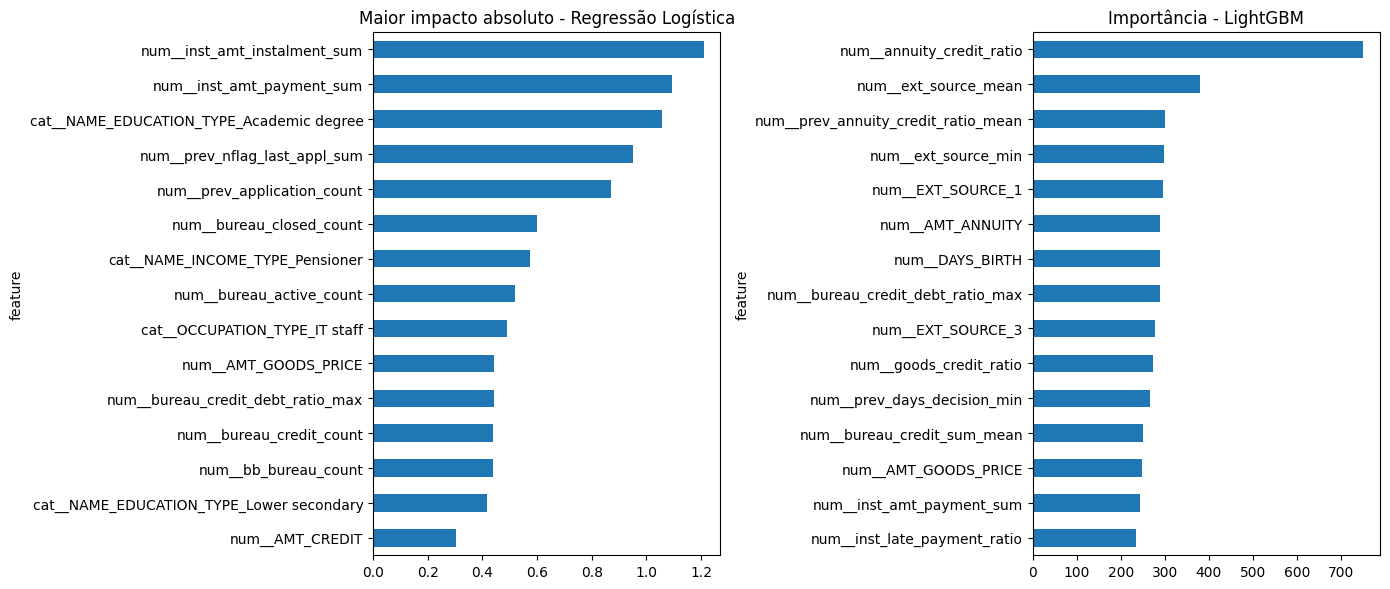

In [46]:
from IPython.display import display

feature_names_escolhido = modelo_escolhido.named_steps["preprocess"].get_feature_names_out()
estimador_escolhido = modelo_escolhido.named_steps["model"]

if hasattr(modelLR.named_steps["model"], "coef_"):
    feature_names_lr = modelLR.named_steps["preprocess"].get_feature_names_out()
    coeficientes_lr = pd.DataFrame({
        "feature": feature_names_lr,
        "coeficiente_regressao_logistica": modelLR.named_steps["model"].coef_[0]
    })
    coeficientes_lr["impacto_absoluto"] = coeficientes_lr["coeficiente_regressao_logistica"].abs()
    coeficientes_lr = coeficientes_lr.sort_values("impacto_absoluto", ascending=False)
    display(coeficientes_lr.head(20))

if hasattr(estimador_escolhido, "feature_importances_"):
    importancias_modelo = pd.DataFrame({
        "feature": feature_names_escolhido,
        "importancia_modelo_escolhido": estimador_escolhido.feature_importances_
    }).sort_values("importancia_modelo_escolhido", ascending=False)
else:
    importancias_modelo = pd.DataFrame({
        "feature": feature_names_escolhido,
        "impacto_absoluto_modelo_escolhido": abs(estimador_escolhido.coef_[0])
    }).sort_values("impacto_absoluto_modelo_escolhido", ascending=False)

principais_fatores_modelo = importancias_modelo.head(8)["feature"].tolist()

display(importancias_modelo.head(20))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

coeficientes_lr.head(15).sort_values("impacto_absoluto").plot.barh(
    x="feature",
    y="impacto_absoluto",
    ax=axes[0],
    legend=False,
    title="Maior impacto absoluto - Regressão Logística"
)

plot_col = importancias_modelo.columns[1]
importancias_modelo.head(15).sort_values(plot_col).plot.barh(
    x="feature",
    y=plot_col,
    ax=axes[1],
    legend=False,
    title=f"Importância - {nome_modelo_escolhido}"
)

plt.tight_layout()
plt.show()

# Análise de um cliente de teste

Selecionamos um cliente do conjunto de teste e calculamos sua probabilidade estimada de inadimplência usando o modelo escolhido. Depois classificamos o risco em faixas simples para facilitar a interpretação.

Essa etapa simula como o modelo poderia apoiar uma análise individual de crédito.

In [47]:
def classificar_risco(prob):
    if prob < threshold_baixo_risco:
        return "Baixo risco"
    if prob < threshold_alto_risco:
        return "Risco moderado"
    return "Alto risco"


def recomendar_decisao(prob):
    if prob < threshold_baixo_risco:
        return "Possível aprovação automática"
    if prob < threshold_alto_risco:
        return "Análise manual"
    return "Revisão crítica / possível recusa"


cliente = X_test.iloc[[0]]
prob_default = modelo_decisao.predict_proba(cliente)[0][1]
risco = classificar_risco(prob_default)
decisao_sugerida = recomendar_decisao(prob_default)

print(f"Probabilidade calibrada de inadimplência: {prob_default:.2%}")
print(f"Classificação: {risco}")
print(f"Decisão sugerida: {decisao_sugerida}")
cliente

Probabilidade calibrada de inadimplência: 3.24%
Classificação: Baixo risco
Decisão sugerida: Possível aprovação automática


c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_REGISTRATION,...,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,NAME_TYPE_SUITE
256571,157500.0,770292.0,30676.5,-105.0,NaN,0.594327,0.427657,688500.0,-13506,-2876.0,...,Cash loans,M,Y,Y,Working,Higher education,Married,House / apartment,Laborers,Family


# Geração da análise textual

A IA generativa recebe os dados do cliente, a probabilidade prevista, a faixa de risco e os principais fatores do modelo. O objetivo é produzir uma justificativa profissional em linguagem natural.

A chave da Groq deve ficar fora do notebook, preferencialmente em uma variável de ambiente chamada `GROQ_API_KEY`.

In [48]:
def criar_prompt(cliente, prob, risco):
    dados_cliente = cliente.to_dict(orient="records")[0]
    return f"""
Você é um analista de crédito de um grande banco.

Dados do cliente:
{dados_cliente}

Probabilidade calibrada estimada de inadimplência: {prob:.2%}
Classificação preliminar do modelo: {risco}
Decisão sugerida pela política inicial: {decisao_sugerida}
Faixas de decisão usadas:
- Baixo risco: probabilidade < {threshold_baixo_risco:.2f}
- Risco moderado: {threshold_baixo_risco:.2f} a {threshold_alto_risco:.2f}
- Alto risco: probabilidade >= {threshold_alto_risco:.2f}
Variáveis mais relevantes para o modelo: {principais_fatores_modelo}

Considere boas práticas de crédito, mas trate o modelo como apoio à decisão, não como decisão automática.

Responda:
- Classificação de risco
- Principais fatores observados nos dados
- Recomendação
- Justificativa profissional
- Cuidados ou informações adicionais que o banco deveria verificar
"""

In [49]:
import os
from getpass import getpass
from groq import Groq


def obter_groq_api_key():
    api_key = os.environ.get("GROQ_API_KEY")

    if not api_key:
        try:
            from google.colab import userdata
            api_key = userdata.get("API_Key_GROQ")
        except Exception:
            api_key = None

    if not api_key:
        api_key = getpass("Cole sua GROQ_API_KEY: ").strip()

    if not api_key:
        raise ValueError("GROQ_API_KEY não informada. Configure a chave da Groq para gerar a análise textual.")

    os.environ["GROQ_API_KEY"] = api_key
    return api_key


client = Groq(api_key=obter_groq_api_key())

prompt = criar_prompt(cliente, prob_default, risco)

try:
    response = client.chat.completions.create(
        messages=[
            {"role": "system", "content": "Você é um especialista em risco de crédito."},
            {"role": "user", "content": prompt}
        ],
        model="llama-3.3-70b-versatile",
        temperature=0.2
    )

    analise = response.choices[0].message.content
    print(analise)
except Exception as erro:
    print("Não foi possível gerar a análise com a Groq.")
    print(f"Tipo do erro: {type(erro).__name__}")
    print(f"Detalhe: {erro}")
    print("Verifique se a chave GROQ_API_KEY está correta e se o modelo configurado está disponível na sua conta.")

**Classificação de Risco:**
Com base nos dados fornecidos e considerando as boas práticas de crédito, a classificação de risco para este cliente é **Risco Moderado**. Embora a probabilidade calibrada estimada de inadimplência seja de 3,24%, o que está acima do limite para "Baixo Risco" (probabilidade < 0,10), é importante considerar outros fatores além da probabilidade de inadimplência para uma avaliação mais completa do risco.

**Principais Fatores Observados nos Dados:**
Os principais fatores observados nos dados que influenciam a classificação de risco incluem:
- **Anuidade/Crédito (annuity_credit_ratio)**: Uma razão alta pode indicar um comprometimento significativo da renda do cliente com pagamentos de anuidade, potencialmente aumentando o risco de inadimplência.
- **Média das Fontes Externas (ext_source_mean)**: Uma pontuação alta nas fontes externas pode indicar um histórico de crédito saudável, mas é importante considerar a consistência dessas pontuações.
- **Razão entre Anuida